In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:

sys.path.append(str(Path().resolve() / 'py_modules')) 


from rebin_utils import downsample

#  H II region Data

In [3]:
line        = r'[O III] $\lambda$ 5007'
lambda_rest = 5006.9
line_id     = 'O'


In [4]:
# Data from observations
bins        = 0

region     = 'NGC 346'
name_reg   = 'N346'
reg_id     = 'N346'
inst       = 'MUSE'
inst_id    = 'MUSE'
type_obj   = 'H II region'

pix        = 0.2   # Instrument resolution [arcsec/pix]
dist       = 62000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with matrix data binning can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id 
name_id      =  inst_id + '-' + reg_id + '-' + line_id + '-' + 'bin' + str(bins)
print(name_file)
print(name_id)

MUSE-N346-O
MUSE-N346-O-bin0


In [5]:
_data = json.load(open('observations/'+ name_file + '-m.json'))
sb    = np.array(_data['sb'])
vv    = np.array(_data['vv'])
ss    = np.array(_data['ss'])

In [6]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv*ss) | (sb < 0.0)
#m = m | (sb > 6e4) 
sb[m] = 0.0
vv[m] = np.nanmean(vv)
ss[m] = 0.0
sb   /= sb.max()

mu = vv.mean()
sigma = vv.std()
n = 3

good = (~m) & (sb > 1e-3) & (vv > (mu - n*sigma)) & (vv < (mu + n*sigma))

In [7]:
vv_m = np.where(good, vv, mu)     
sb_m = np.where(good, sb, 0)     
ss_m = np.where(good, ss, np.nan)   

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_14052\3798436418.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


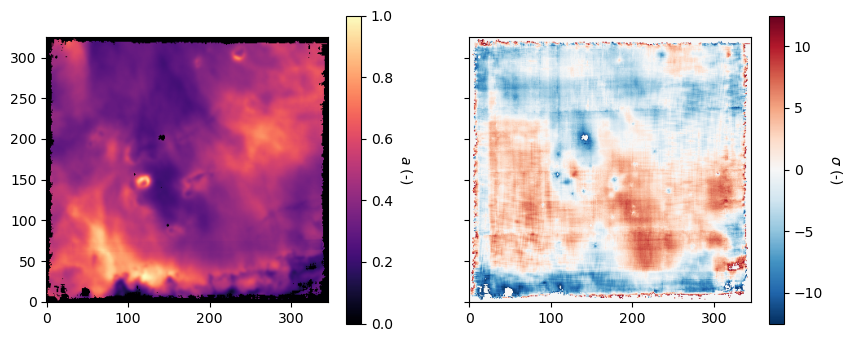

In [8]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [9]:
trim = (slice(20, 315), slice(10, 330))
trim

(slice(20, 315, None), slice(10, 330, None))

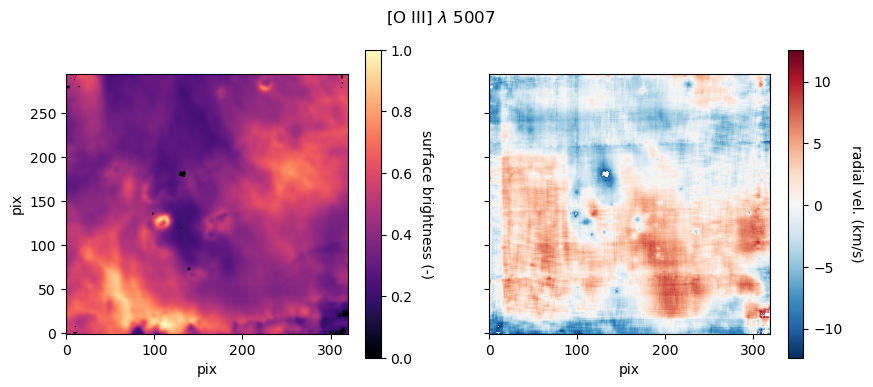

In [10]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)

im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [11]:
N = np.sqrt(vv_m[trim].shape[0] * vv_m[trim].shape[1]) * pix * pc
N

np.float64(18.470665744008677)

In [12]:
sig = np.nanstd(vv_m[trim])
sig

np.float64(3.4399521846558407)

# Downsample

# Export

In [13]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [14]:
hdu_m0 = fits.ImageHDU(data=sb_m[trim],  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m[trim],  name='MOM1')
hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
hdu_mk = fits.ImageHDU(data=good[trim].astype(np.uint8) ,  name='MASK')

In [15]:
hdul = fits.HDUList([primary, hdu_m0, hdu_m1, hdu_m2, hdu_mk])
hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

In [16]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()

Filename: fits_ready/MUSE-N346-O-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (320, 295)   float64   
  2  MOM1          1 ImageHDU         8   (320, 295)   float64   
  3  MOM2          1 ImageHDU         8   (320, 295)   float64   
  4  MASK          1 ImageHDU         8   (320, 295)   uint8   
